In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

import tensorflow_datasets as tfds

#Data

for data set we use tensorflow dataset. food 101.

In [2]:
ds, ds_info = tfds.load('food101', shuffle_files=True, as_supervised=True, with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/75750 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/2.0.0.incompleteJEZQD9/food101-train.tfrecord*...:   0%|          …

Generating validation examples...:   0%|          | 0/25250 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/2.0.0.incompleteJEZQD9/food101-validation.tfrecord*...:   0%|     …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


In [3]:
train_data = ds['train']
validation_data = ds['validation']

in this dataset hot dog labled 55

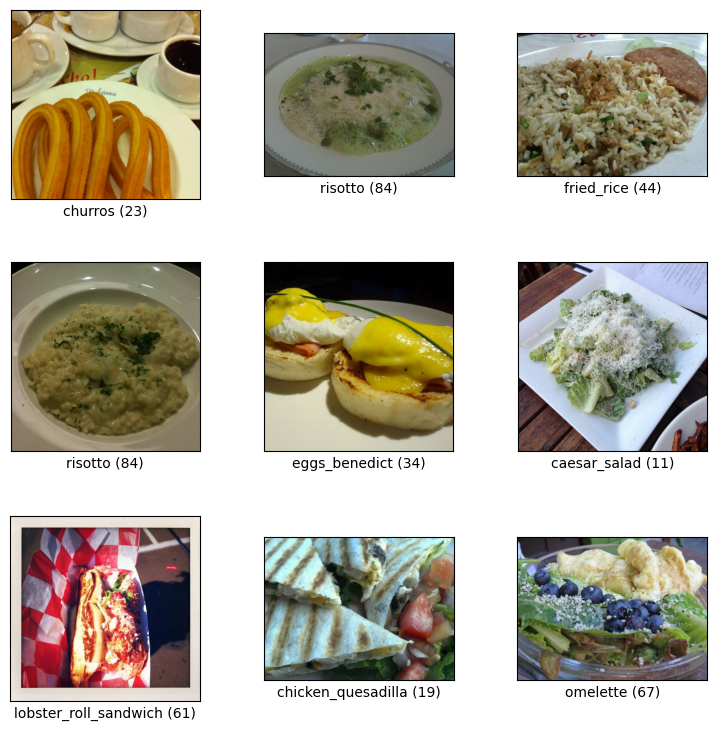

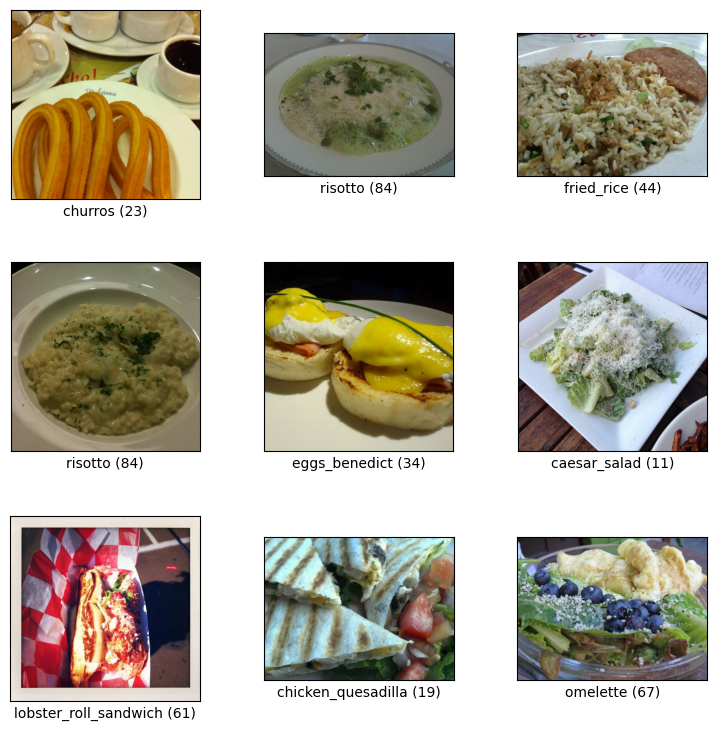

In [4]:
tfds.show_examples(train_data, ds_info)

+ as we can see the pictures are in the diffrent shape so we need to reshape it to square               
+ we need to map label to 0 and 1         
+ we need to cast it into the int32 ==> tf.cast     
+ do the same for validation data

In [5]:
train_data = train_data.map(
    lambda image, label:( tf.cast(tf.image.resize(image, [128,128]) , dtype = tf.int32) , tf.cast(label == 55, dtype= tf.int32) )
)
validation_data = validation_data.map(
    lambda image, label:( tf.cast(tf.image.resize(image, [128,128]) , dtype = tf.int32) , tf.cast(label == 55, dtype= tf.int32) )
)

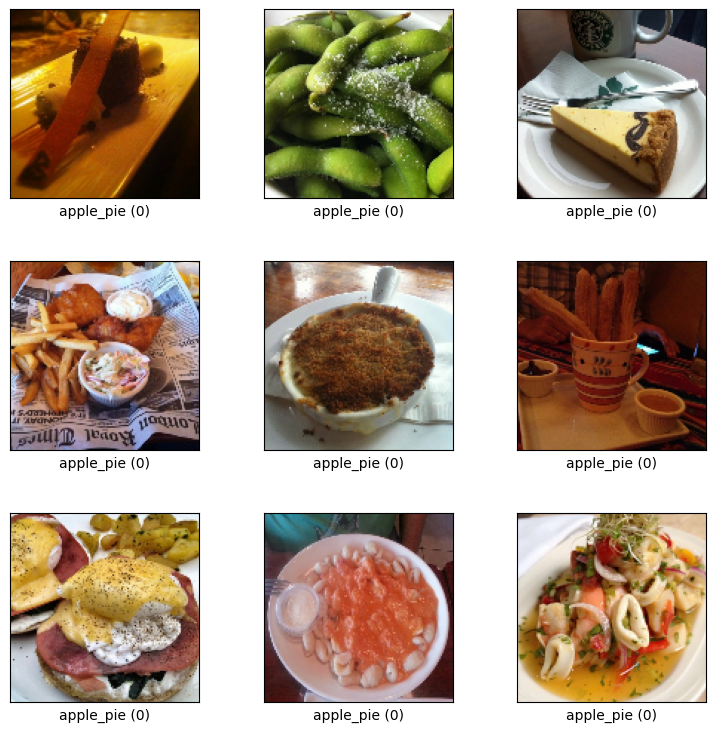

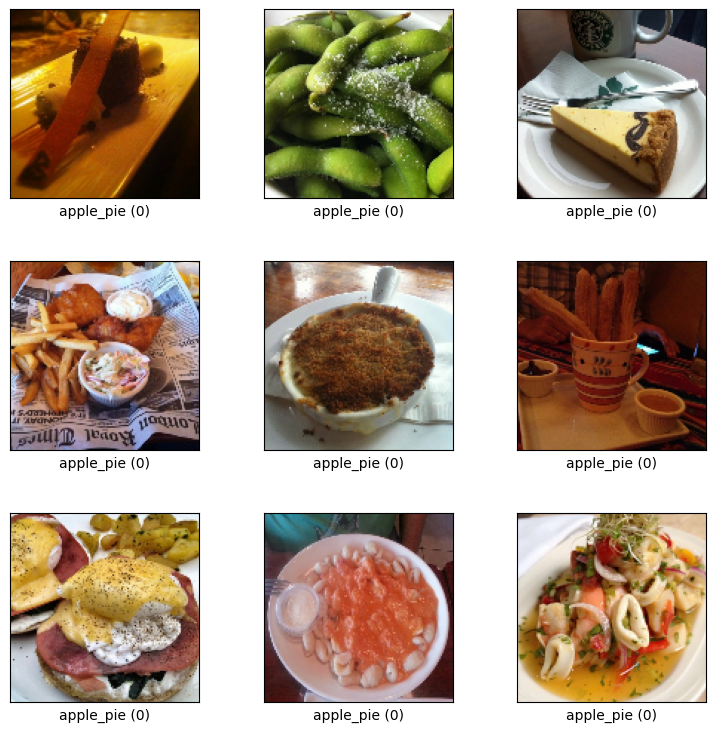

In [6]:
tfds.show_examples(train_data , ds_info)

we have a large of not hot dog picture and small data for hot gog picture so we need more hot dog picture for training ==> we repeat the poctures of hot dog ==> usind .fiter

In [7]:
train_hotdogs = train_data.filter(lambda _, label: label==1).repeat(3)
train_nothotdogs = train_data.filter(lambda _, label: label ==0 )

In [8]:
validation_hotdogs = validation_data.filter(lambda _, label: label==1).repeat(3)
validation_nothotdogs = validation_data.filter(lambda _, label: label ==0 )

+ we sample of our data to have two equal sets of both categories ( hot gosd and not hot dogs)  
+ we do cache and batch and prefetch for save timimg and memmory

In [9]:
train_data = tf.data.Dataset.sample_from_datasets([train_hotdogs, train_nothotdogs], weights= [0.5, 0.5], stop_on_empty_dataset= True)
train_data = train_data.cache().batch(16).prefetch(tf.data.AUTOTUNE)

validation_data = tf.data.Dataset.sample_from_datasets([validation_hotdogs, validation_nothotdogs], weights= [0.5, 0.5], stop_on_empty_dataset= True)
validation_data = validation_data.cache().batch(16).prefetch(tf.data.AUTOTUNE)

chack for everything is OK

In [10]:
for image, label in train_data.take(3):
  print(image[0][0][0])
  print(label)

tf.Tensor([1 1 1], shape=(3,), dtype=int32)
tf.Tensor([1 0 1 1 1 0 0 1 1 1 0 1 0 0 0 1], shape=(16,), dtype=int32)
tf.Tensor([203  85   3], shape=(3,), dtype=int32)
tf.Tensor([0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0], shape=(16,), dtype=int32)
tf.Tensor([ 6 10 13], shape=(3,), dtype=int32)
tf.Tensor([0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1], shape=(16,), dtype=int32)


# Neural Network implemention

+ **model.add(layers.Flatten())**:  
 This layer flattens the multi-dimensional output of the preceding convolutional layers into a one-dimensional array.

+ **model.add(layers.Dense(128, activation='relu'))**:   
 This line adds a fully connected layer with 128 neurons. Dence means Each neuron in this layer is connected to every neuron in the previous layer (in this case, the flattened layer). The 'relu' activation function (Rectified Linear Unit) is applied to the output of each neuron. This activation function introduces non-linearity into the network, allowing it to learn complex patterns in the data.

+ **model.add(layers.Dense(1))**:   
Finally, this line adds the output layer with a single neuron. Since this appears to be a binary classification task (where the output is either 0 or 1), a single neuron is sufficient to produce the output. There is no activation function specified here, which means it defaults to a linear activation

In [11]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

In [12]:
random.seed(0)
model = models.Sequential()
model.add(layers.Rescaling(1./255))
model.add(data_augmentation)
model.add(layers.Conv2D(128, (3,3), activation = 'relu', input_shape = (128, 128, 3)))
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(128, (3,3), activation = 'relu'))
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(128, (3,3), activation = 'relu'))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation = 'relu'))
model.add(layers.Dropout(0.25))
model.add(layers.Dense(1))

**model.compile()**:

+ This method is used to configure the learning process before training the model.  
+ It involves specifying important settings such as the optimizer, loss function, and evaluation metrics.  
+ model.compile() prepares the model for training but does not involve any actual training data.

In [13]:
learning_rate = 0.0001
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate),
    loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics = ['accuracy']
)

**model.fit():**

+ This method is used to actually train the model.  
+ It involves providing training data to the model and updating its weights based on that data.  
+ model.fit() includes parameters such as the number of training epochs, batch size, and training and validation data.

note :  
**verbose=0**: Silent mode. Training progress will not be printed to the console.

**verbose=1**: Default mode. Progress bars will be displayed for each epoch, showing the training and validation metrics.



In [ ]:
history = model.fit(
    train_data,
    validation_data = validation_data,
    epochs = 50,
    verbose = 1
)

Epoch 1/50
277/277 [==============================] - 1145s 4s/step - loss: 0.6946 - accuracy: 0.4914 - val_loss: 0.6783 - val_accuracy: 0.4497
Epoch 2/50
277/277 [==============================] - 641s 2s/step - loss: 0.6781 - accuracy: 0.5269 - val_loss: 0.6645 - val_accuracy: 0.4820
Epoch 3/50
277/277 [==============================] - 635s 2s/step - loss: 0.6695 - accuracy: 0.5427 - val_loss: 0.6499 - val_accuracy: 0.5583
Epoch 4/50
277/277 [==============================] - 637s 2s/step - loss: 0.6501 - accuracy: 0.5723 - val_loss: 0.6266 - val_accuracy: 0.5532
Epoch 5/50
277/277 [==============================] - 640s 2s/step - loss: 0.6302 - accuracy: 0.5953 - val_loss: 0.6097 - val_accuracy: 0.6023
Epoch 6/50
277/277 [==============================] - 639s 2s/step - loss: 0.6175 - accuracy: 0.6168 - val_loss: 0.5724 - val_accuracy: 0.6882
Epoch 7/50
277/277 [==============================] - 634s 2s/step - loss: 0.6039 - accuracy: 0.6355 - val_loss: 0.5753 - val_accuracy: 0.658

our datas are overfitting
so we should try to improve the model